<a href="https://colab.research.google.com/github/agarwalcodenilansh/Silver_Market_Analysis/blob/main/Silver_Price_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install yfinance pandas matplotlib

In [ ]:
import yfinance as yf
import pandas as pd
from datetime import datetime

In [ ]:
tickers = {
    "SI=F": "Silver",
    "GC=F": "Gold",
    "DX-Y.NYB": "USD_Index"
}

In [ ]:
end_date = datetime.now().strftime('%Y-%m-%d')
start_date = "2016-01-01"
print(f"Fetching data for: {list(tickers.keys())}...")

Fetching data for: ['SI=F', 'GC=F', 'DX-Y.NYB']...


In [ ]:
raw_data = yf.download(list(tickers.keys()), start=start_date, end=end_date, auto_adjust=True)

[*********************100%***********************]  3 of 3 completed


In [ ]:
df = raw_data['Close'].copy()

In [ ]:
df = df.rename(columns=tickers)

In [ ]:
df = df.ffill().dropna()

In [ ]:
print("\nSuccess! Data Preview:")
print(df.head())


Success! Data Preview:
Ticker      USD_Index         Gold  Silver
Date                                      
2016-01-04  98.870003  1075.099976  13.817
2016-01-05  99.400002  1078.400024  13.949
2016-01-06  99.180000  1091.900024  13.957
2016-01-07  98.220001  1107.699951  14.335
2016-01-08  98.540001  1097.800049  13.908


In [ ]:
df.to_csv("silver_market_data.csv")

In [ ]:
print("\nFirst 5 rows of your dataset:")
print(df.head())


First 5 rows of your dataset:
Ticker      USD_Index         Gold  Silver
Date                                      
2016-01-04  98.870003  1075.099976  13.817
2016-01-05  99.400002  1078.400024  13.949
2016-01-06  99.180000  1091.900024  13.957
2016-01-07  98.220001  1107.699951  14.335
2016-01-08  98.540001  1097.800049  13.908


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("silver_market_data.csv", index_col= 0,parse_dates=True)

In [ ]:
df['Gold_Silver_Ratio'] = df['Gold'] / df['Silver']

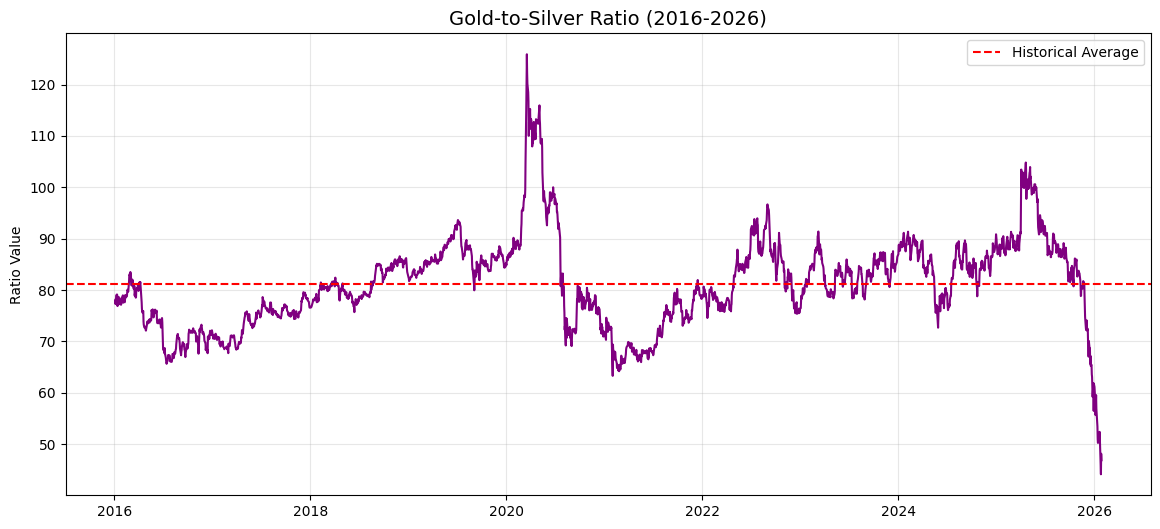

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Gold_Silver_Ratio'], color='purple', linewidth=1.5)
plt.axhline(df['Gold_Silver_Ratio'].mean(), color='red', linestyle='--', label='Historical Average')
plt.title('Gold-to-Silver Ratio (2016-2026)', fontsize=14)
plt.ylabel('Ratio Value')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
corr_matrix = df.corr()

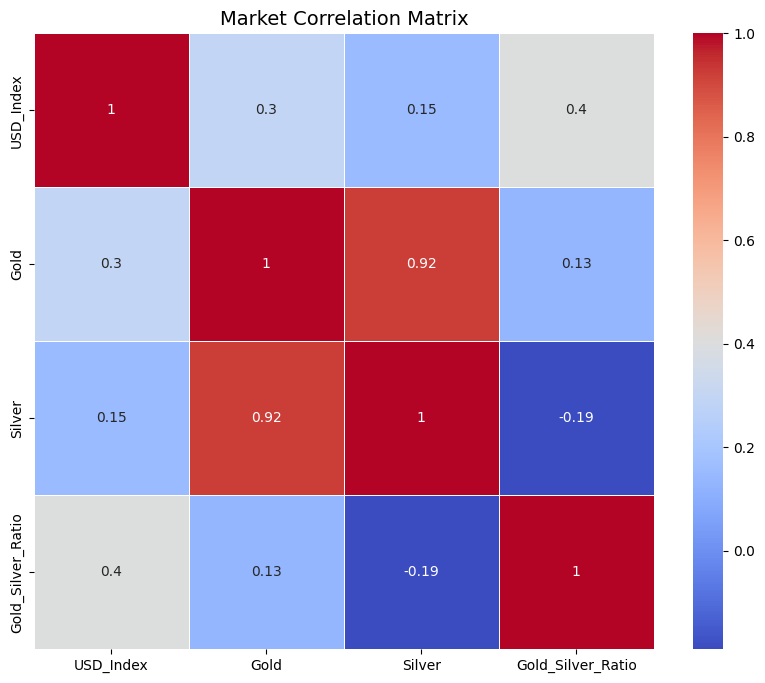

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Market Correlation Matrix', fontsize=14)
plt.show()

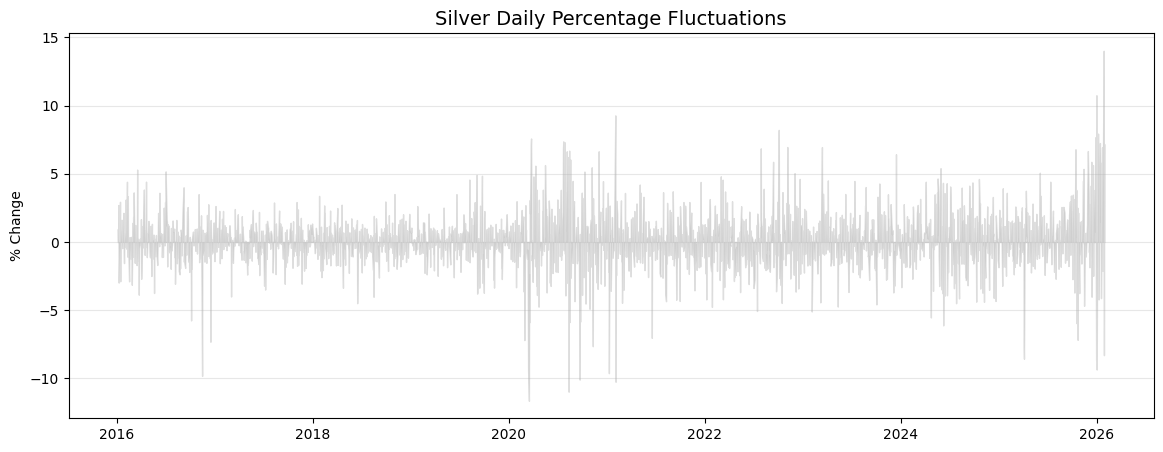

In [ ]:
df['Silver_Daily_Return'] = df['Silver'].pct_change() * 100

plt.figure(figsize=(14, 5))
plt.fill_between(df.index, df['Silver_Daily_Return'], color='silver', alpha=0.5)
plt.title('Silver Daily Percentage Fluctuations', fontsize=14)
plt.ylabel('% Change')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
delta = df['Silver'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()

rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))


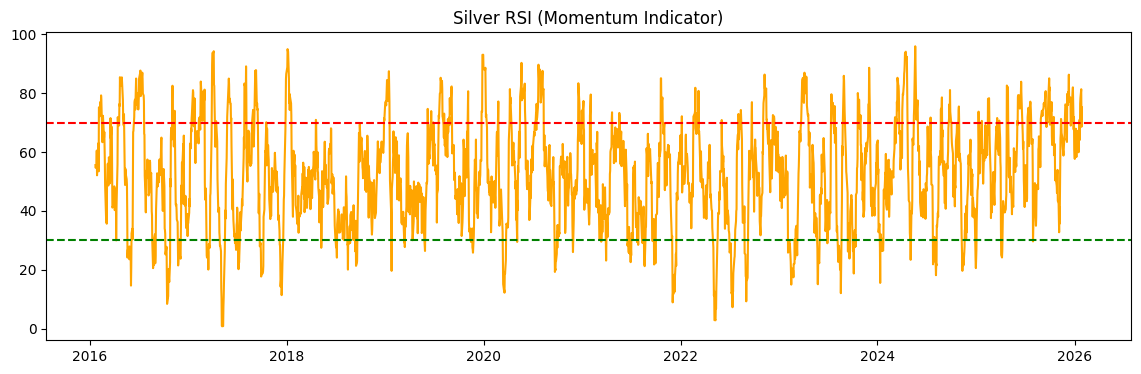

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df['RSI'], color='orange')
ax.axhline(70, color='red', linestyle='--')
ax.axhline(30, color='green', linestyle='--')
plt.title('Silver RSI (Momentum Indicator)')
plt.show()

In [ ]:
df['SMA50'] = df['Silver'].rolling(window=50).mean()
df['SMA200'] = df['Silver'].rolling(window=200).mean()

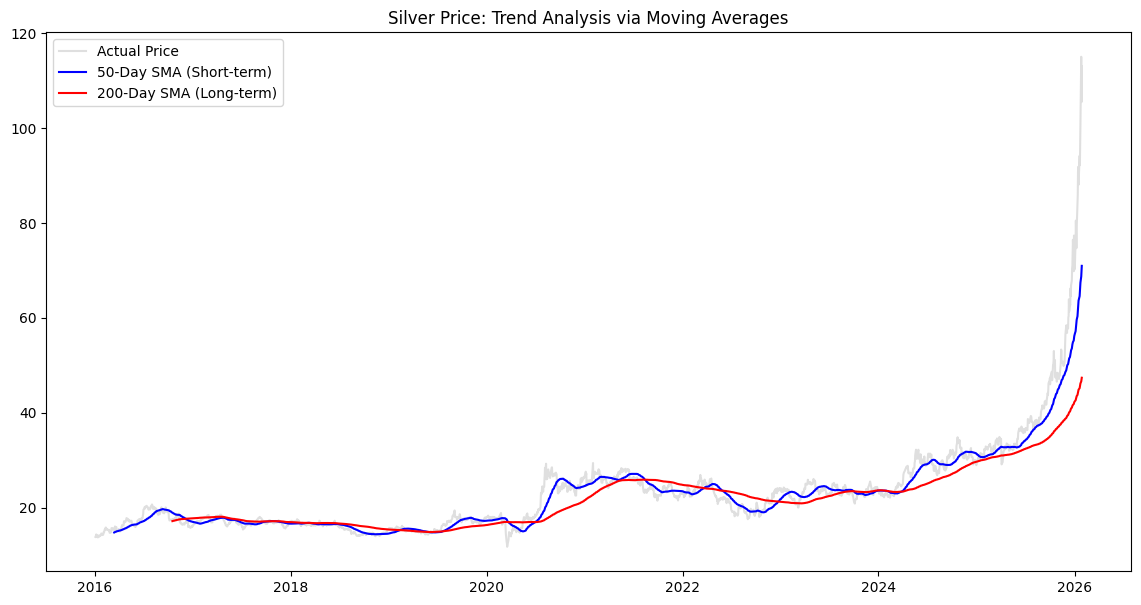

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(df['Silver'], label='Actual Price', alpha=0.5, color='silver')
plt.plot(df['SMA50'], label='50-Day SMA (Short-term)', color='blue')
plt.plot(df['SMA200'], label='200-Day SMA (Long-term)', color='red')
plt.title('Silver Price: Trend Analysis via Moving Averages')
plt.legend()
plt.show()

In [ ]:
df['Month'] = df.index.month
monthly_seasonality = df.groupby('Month')['Silver'].pct_change().mean() * 100

/tmp/ipython-input-927254586.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=months_labels, y=monthly_seasonality.values, palette='viridis')


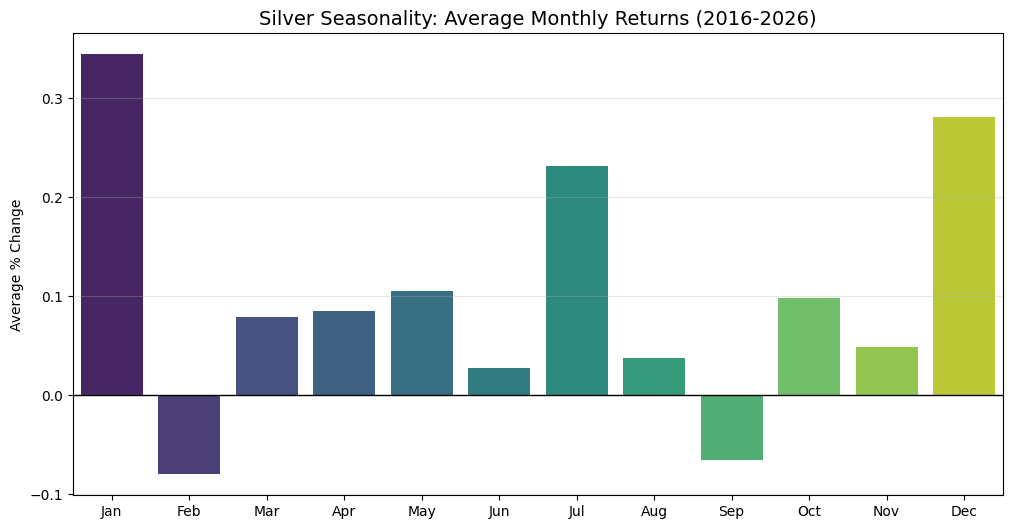

In [ ]:
df['Daily_Return'] = df['Silver'].pct_change() * 100
monthly_seasonality = df.groupby(df.index.month)['Daily_Return'].mean()

months_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(12, 6))
sns.barplot(x=months_labels, y=monthly_seasonality.values, palette='viridis')

plt.title('Silver Seasonality: Average Monthly Returns (2016-2026)', fontsize=14)
plt.ylabel('Average % Change')
plt.axhline(0, color='black', linewidth=1) # Adds a baseline at 0
plt.grid(axis='y', alpha=0.3)
plt.show()

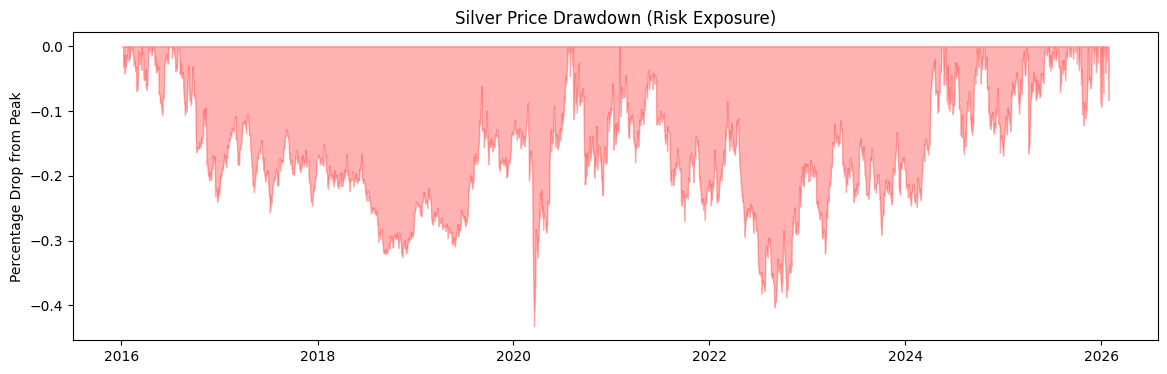

In [ ]:
# Calculate the running maximum
rolling_max = df['Silver'].cummax()
drawdown = (df['Silver'] - rolling_max) / rolling_max

plt.figure(figsize=(14, 4))
plt.fill_between(df.index, drawdown, color='red', alpha=0.3)
plt.title('Silver Price Drawdown (Risk Exposure)')
plt.ylabel('Percentage Drop from Peak')
plt.show()

In [ ]:
!pip install prophet

In [ ]:
from prophet import Prophet
model_df = df.reset_index()[['Date','Silver']]
model_df.columns = ['ds','y']
model = Prophet(daily_seasonality=True , yearly_seasonality= True)
model.fit(model_df)

In [ ]:
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

             ds       yhat  yhat_lower  yhat_upper
2619 2026-04-24  56.874938   51.630460   62.315201
2620 2026-04-25  56.777851   51.351317   62.203073
2621 2026-04-26  56.777594   51.197727   62.385107
2622 2026-04-27  56.882810   51.273336   61.997097
2623 2026-04-28  56.936134   51.823173   62.449692


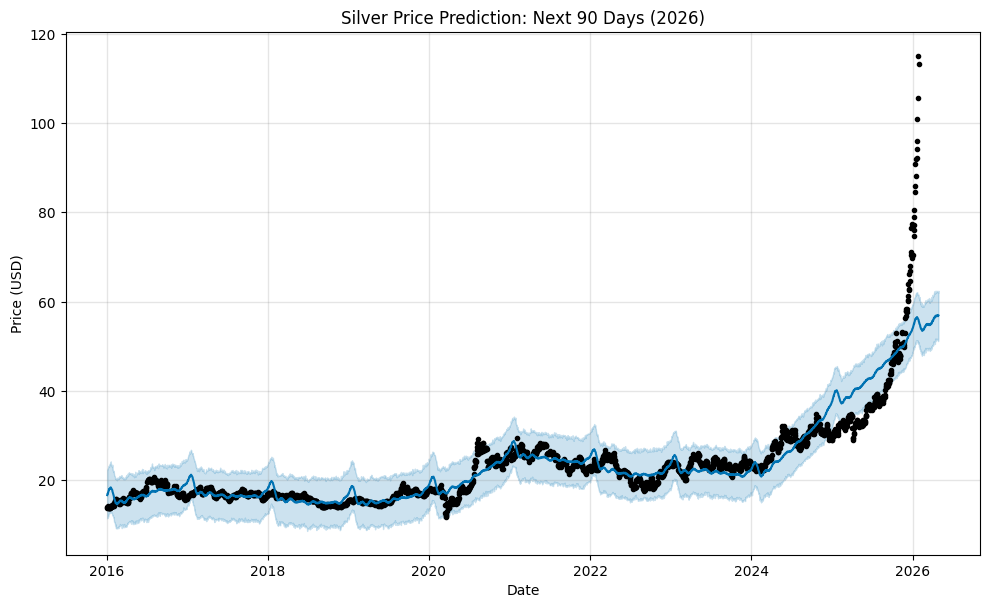

In [ ]:
fig1 = model.plot(forecast)
plt.title("Silver Price Prediction: Next 90 Days (2026)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.show()

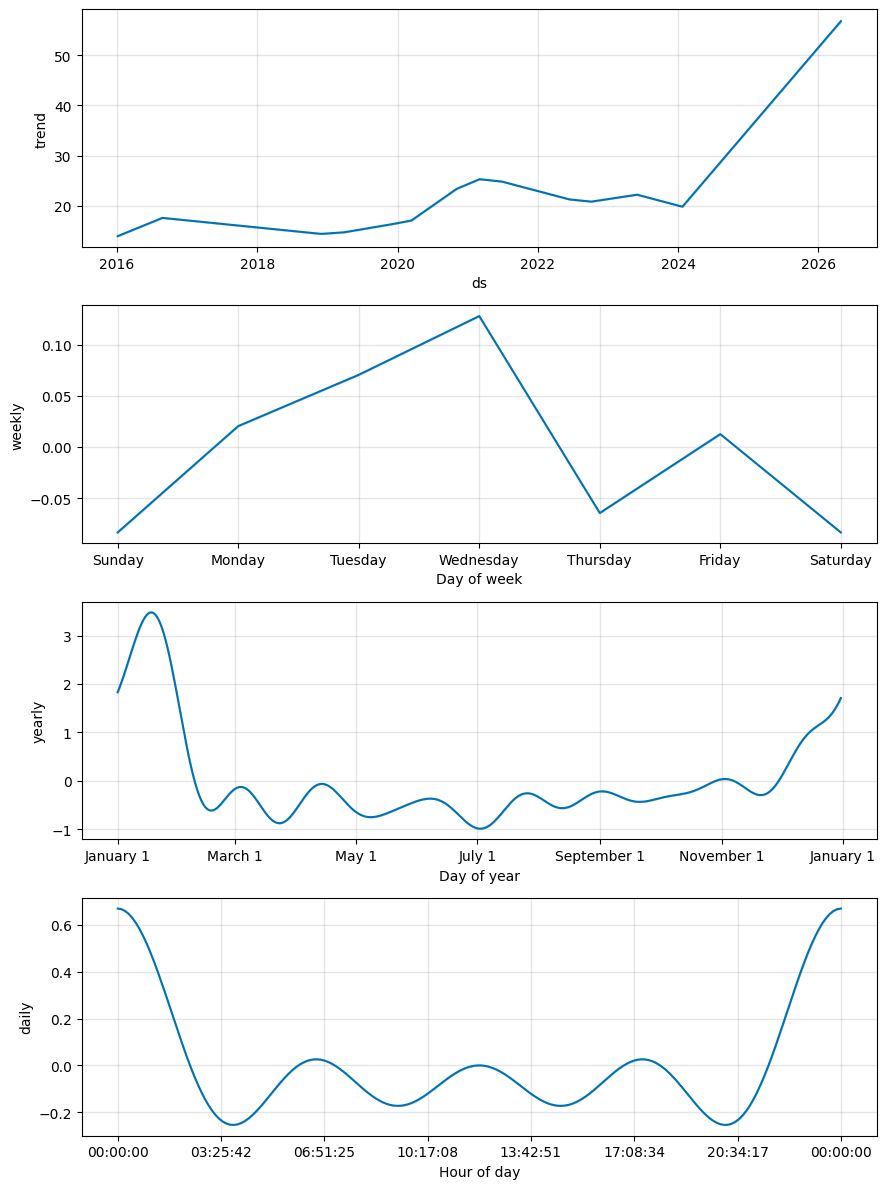

In [ ]:
fig2 = model.plot_components(forecast)
plt.show()

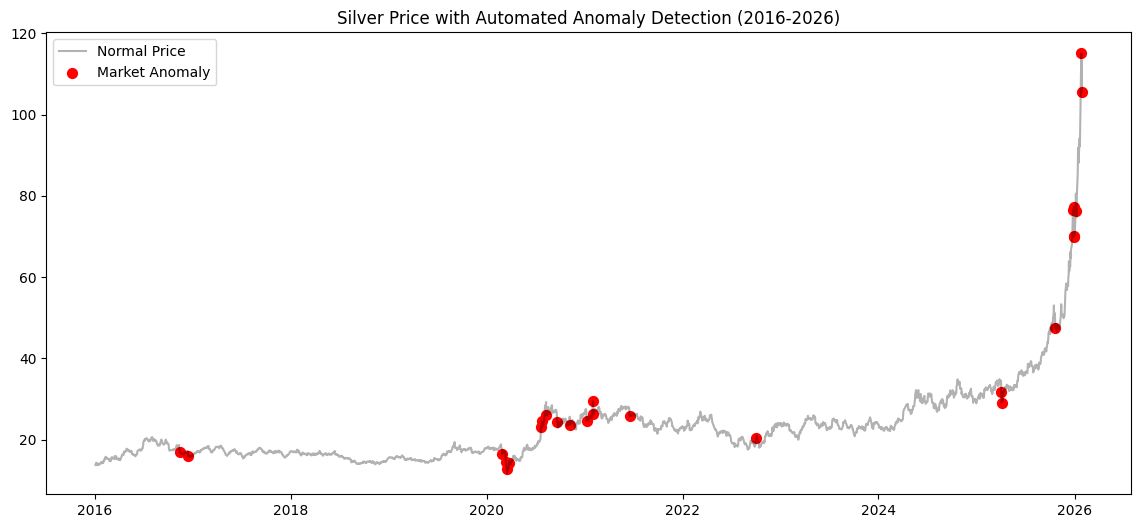

In [ ]:
from sklearn.ensemble import IsolationForest

df['Returns'] = df['Silver'].pct_change().fillna(0)

iso_forest = IsolationForest(contamination=0.01, random_state=42)
df['Anomaly'] = iso_forest.fit_predict(df[['Returns']])

anomalies = df[df['Anomaly'] == -1]

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Silver'], color='black', alpha=0.3, label='Normal Price')
plt.scatter(anomalies.index, anomalies['Silver'], color='red', label='Market Anomaly', s=50)
plt.title('Silver Price with Automated Anomaly Detection (2016-2026)')
plt.legend()
plt.show()

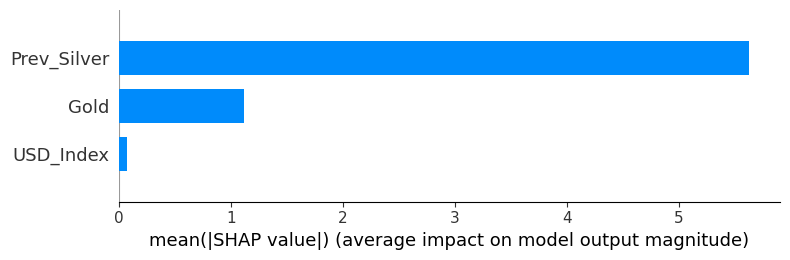

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import shap
df['Prev_Silver'] = df['Silver'].shift(1)
features = ['Gold', 'USD_Index', 'Prev_Silver']
X = df[features].dropna()
y = df['Silver'].iloc[1:]
model_rf = RandomForestRegressor(n_estimators=100)
model_rf.fit(X, y)
explainer = shap.TreeExplainer(model_rf)
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values, X, plot_type="bar")

In [ ]:
from google.colab import auth
auth.authenticate_user()
import gspread
from google.auth import compute_engine
from google.colab import auth
from google.auth import default
creds, _ = default()
gc = gspread.authorize(creds)
sh = gc.open('Silver_Project_Data')
worksheet = sh.get_worksheet(0)

In [ ]:
df_export = df.reset_index()
df_export['Date'] = df_export['Date'].astype(str)

In [ ]:
# 1. Replace Infinity with 0 and NaN with an empty string
df = df.replace([float('inf'), float('-inf')], 0)
df = df.fillna("")

# 2. Now proceed with your export code
df_export = df.reset_index()
df_export['Date'] = df_export['Date'].astype(str)

# 3. Update the worksheet
worksheet.clear()
worksheet.update([df_export.columns.values.tolist()] + df_export.values.tolist())

print("Success! Data is now clean and synced.")

Success! Data is now clean and synced.
